# Sub-cluster Cluster 8 — Resolving TSPC vs. T-FAP

**Input:** `data/Cherief_scRNA-seq/GSE244921_processed.h5ad`  
**Goal:** Split the mixed PDGFRα+ stromal cluster (cluster 8 from notebook 01) into TSPC (Tppp3+) and T-FAP (Pi16+/Sfrp2+/Tppp3−) sub-populations.

**Strategy:** Re-use the PCA embedding from the full object, then re-run `neighbors` and `UMAP` restricted to cluster 8 cells only. This reveals within-cluster structure without interference from other cell types.

**Result summary (Leiden res=0.2, 4 sub-clusters):**
- **Cluster 3 → TSPC:** Tppp3 mean=1.755, 94.5% above-average; highest Cd248, Cd34, Prg4; Sfrp2 near-absent (mean=−0.005); top DEGs include Cd55 (complement regulator on progenitors) and Ptgs1 (COX-1, repair signaling). Strongly TrkAWT-enriched (15.8% vs 6.7%).
- **Cluster 1 → T-FAP:** Pi16 mean=1.633, Sfrp2 mean=1.347; lowest Tppp3; highest Pdgfra; top DEGs are complement genes (C3, C4b, Serping1) — T-FAPs are complement-producing. TrkAF592A-enriched (38.4% vs 26.3%).
- **Cluster 2 → Tenogenic progenitor:** Tppp3-negative; mildly TrkAF592A-enriched (23.9% vs 18.4%); top DEGs are tendon ECM genes (Thbs4, Kera, Col11a1) — likely committed toward tenogenic fate, possibly representing cells exiting the TSPC compartment under denervation pressure.
- **Cluster 0 → Stromal:** intermediate marker expression; identity established by unbiased DEGs — imprinted genes (Plagl1, Mest, H19) — an epigenetically distinct stromal state. Mildly TrkAWT-enriched (39.5% vs 31.0%).

**Output:** `data/Cherief_scRNA-seq/GSE244921_cluster8_sub.h5ad` (cluster 8 sub-object) and `data/Cherief_scRNA-seq/GSE244921_processed_subclustered.h5ad` (full object with `cell_type` annotation propagated back).

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 2
sc.settings.figdir = '../../figures/Cherief_scRNA-seq/'

## 1. Load processed object

In [2]:
full = sc.read_h5ad('../../data/Cherief_scRNA-seq/GSE244921_processed.h5ad')
print(full)
print('\nLeiden cluster sizes:')
print(full.obs['leiden'].value_counts().sort_index())

AnnData object with n_obs × n_vars = 22615 × 21761
    obs: 'condition', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'condition_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Leiden cluster sizes:
leiden
0     2834
1      348
2     1418
3     1690
4     3449
5      643
6     2703
7      681
8     3900
9     1417
10    1518
11     505

## 2. Subset to cluster 8

In [3]:
sub = full[full.obs['leiden'] == '8'].copy()
print(f'Cluster 8: {sub.n_obs} cells')
print('\nCondition split:')
print(sub.obs['condition'].value_counts())

Cluster 8: 3900 cells

Condition split:
condition
TrkAWT       2094
TrkAF592A    1806
Name: count, dtype: int64


**Cluster 8 composition:** 3,900 cells — 2,094 TrkAWT (innervated) and 1,806 TrkAF592A (denervated). The slight raw-count imbalance (54% vs 46%) should not be interpreted as evidence of progenitor expansion without first verifying whether it exceeds the overall TrkAWT:TrkAF592A ratio in the full 22,615-cell dataset. Condition-normalised proportions per sub-cluster are computed and interpreted in §7.

## 3. Re-embed within cluster 8

We re-run `neighbors` and `UMAP` on the PCA coordinates already computed for the full dataset (`X_pca`). This re-builds the neighborhood graph using only the cluster 8 cells, allowing Leiden to detect finer sub-structure without interference from other cell types.

`n_neighbors=15` is used (smaller than the default 30) to reflect the smaller population size.

In [4]:
sc.pp.neighbors(sub, n_pcs=20, n_neighbors=15, use_rep='X_pca')
sc.tl.umap(sub)

computing neighbors
    finished (0:00:10)
computing UMAP
    finished (0:00:03)


C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\4211800367.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(sub, color=['Tppp3', 'Pdgfra', 'Pi16', 'condition'],


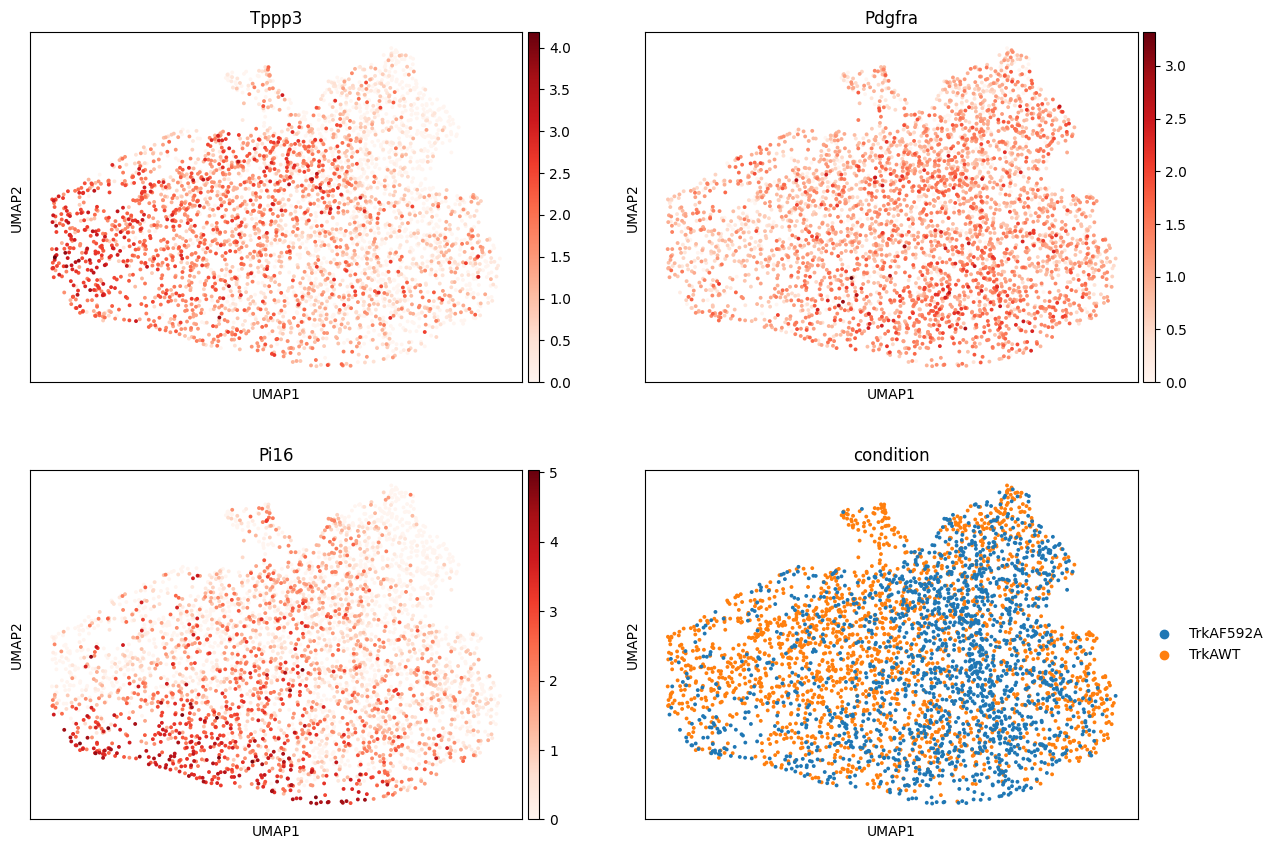

In [5]:
sc.pl.umap(sub, color=['Tppp3', 'Pdgfra', 'Pi16', 'condition'],
           ncols=2, cmap='Reds',
           save='_sub8_sanity.png')

**Sanity check findings:**

- **Tppp3:** Dense in the upper-left region of the UMAP. Expression is focal and not diffuse — confirms a distinct Tppp3+ sub-population exists within cluster 8.
- **Pi16:** Dense at the bottom of the UMAP. Spatially complementary to Tppp3 (upper-left vs. bottom) — the two markers are largely anti-correlated, which is the key prerequisite for TSPC/T-FAP separation.
- **Pdgfra:** Broadly expressed but highest toward the center-right. Notably low in the Tppp3-dense upper-left region. Because all cluster 8 cells are PDGFRα+, this reflects *relative* Pdgfra within the cluster — T-FAP-like cells express it at above-average levels, TSPCs at average or below.
- **Condition:** TrkAWT (orange/innervated) is enriched in a small protrusion at the very top of the UMAP, which co-localises with the Tppp3-high zone. TrkAF592A (blue/denervated) dominates the center and right. **This directly reproduces Cherief et al.'s core finding: innervation maintains the Tppp3+ TSPC compartment, and denervation depletes it.** The biology is visible before any clustering is applied.

## 4. Leiden resolution sweep

Sweep resolutions from 0.2 to 1.0 to find the lowest resolution at which TSPC and T-FAP form distinct partitions.

In [6]:
resolutions = [0.2, 0.4, 0.6, 0.8, 1.0]

for res in resolutions:
    sc.tl.leiden(
        sub, resolution=res,
        key_added=f'leiden_{res}',
        flavor='igraph', n_iterations=2, directed=False
    )
    n = sub.obs[f'leiden_{res}'].nunique()
    print(f'res={res}: {n} sub-clusters')

running Leiden clustering
    finished (0:00:00)
res=0.2: 4 sub-clusters
running Leiden clustering
    finished (0:00:00)
res=0.4: 6 sub-clusters
running Leiden clustering
    finished (0:00:00)
res=0.6: 10 sub-clusters
running Leiden clustering
    finished (0:00:00)
res=0.8: 12 sub-clusters
running Leiden clustering
    finished (0:00:00)
res=1.0: 17 sub-clusters


C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\3570651308.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


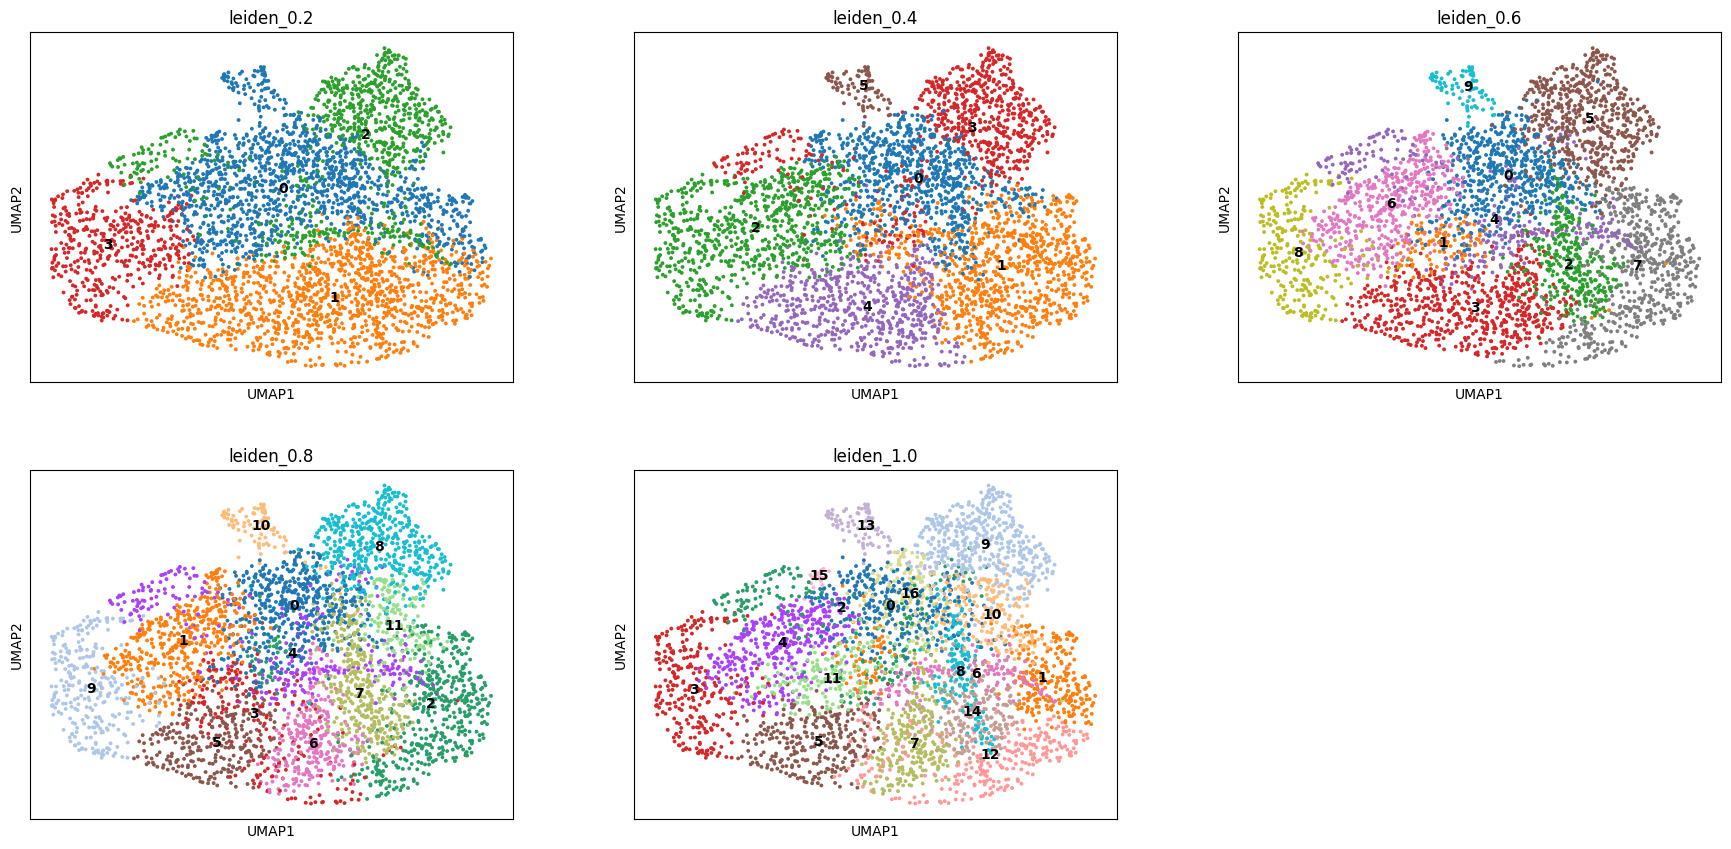

In [7]:
sc.pl.umap(
    sub,
    color=[f'leiden_{res}' for res in resolutions],
    ncols=3, legend_loc='on data',
    save='_sub8_resolution_sweep.png'
)

**Resolution choice — res=0.2 selected (4 sub-clusters):**

Resolution 0.2 gives 4 sub-clusters that map cleanly onto biologically interpretable populations. Higher resolutions (0.6+) fragment the cluster into 10–17 sub-groups with no additional biological meaning at this stage. The 4-cluster solution provides the minimum necessary resolution to separate TSPC from T-FAP while keeping intermediate populations tractable.

Marker validation (§5) confirmed the biological identity of all four sub-clusters using numerical expression tables rather than visual dotplot reading.

## 5. Marker validation at chosen resolution

C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\1028030190.py:5: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


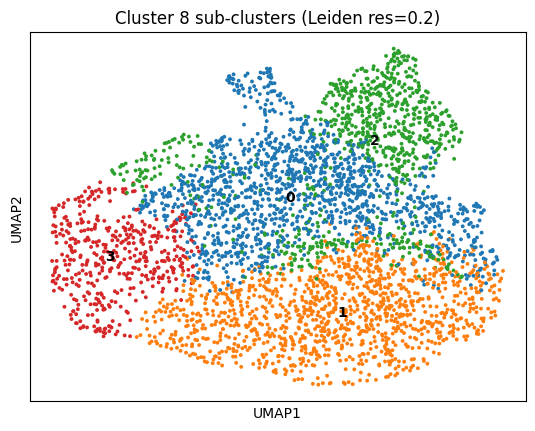

In [8]:
RESOLUTION = 0.2

sub.obs['leiden_sub'] = sub.obs[f'leiden_{RESOLUTION}']

sc.pl.umap(
    sub, color='leiden_sub',
    legend_loc='on data',
    title=f'Cluster 8 sub-clusters (Leiden res={RESOLUTION})',
    save='_sub8_chosen.png'
)

In [9]:
# Candidate markers from Harvey 2019:
#   TSPC (cluster 2): Tppp3, Cd248, Tnxb, Prg4, Cd34
#   T-FAP (cluster 3): Pi16, Dpp4, Ly6a (Sca-1), Sfrp2
#   Shared PDGFRα+ field: Pdgfra
# Note: Dpp4 was found to be highest in the TSPC cluster (3) in this dataset
# (mean=1.425, 48.8%) rather than T-FAP (cluster 1, mean=0.708, 24.1%).
# Dpp4 is NOT a reliable T-FAP discriminator in the Achilles injury context.
# Note: Ly6a is similarly unreliable — it is highest in TSPC (cluster 3, mean=1.785, 99.3%)
# and nearly universal across all sub-clusters (88–99%), giving it no discriminating power here.
# Sfrp2 is the most informative T-FAP marker in this dataset.

tspc_markers = ['Tppp3', 'Cd248', 'Tnxb', 'Prg4', 'Cd34']
tfap_markers = ['Pi16', 'Dpp4', 'Ly6a', 'Sfrp2']
shared       = ['Pdgfra']

all_markers = [g for g in tspc_markers + tfap_markers + shared
               if g in sub.var_names]

print('Markers found in dataset:', all_markers)
print('Missing:', [g for g in tspc_markers + tfap_markers + shared
                   if g not in sub.var_names])

Markers found in dataset: ['Tppp3', 'Cd248', 'Tnxb', 'Prg4', 'Cd34', 'Pi16', 'Dpp4', 'Ly6a', 'Sfrp2', 'Pdgfra']
Missing: []


C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\830882959.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.dotplot(


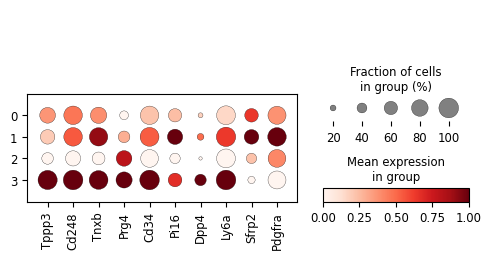

In [10]:
sc.pl.dotplot(
    sub, all_markers, groupby='leiden_sub',
    standard_scale='var',
    save='_sub8_markers.png'
)

In [11]:
# Numerical marker table — used to verify dotplot visual reading
markers_to_check = [g for g in all_markers if g in sub.var_names]

expr = sub[:, markers_to_check].X
if hasattr(expr, 'toarray'):
    expr = expr.toarray()

import numpy as np
df_expr = pd.DataFrame(expr, columns=markers_to_check, index=sub.obs_names)
df_expr['leiden_sub'] = sub.obs['leiden_sub'].values

print('=== Mean scaled expression per sub-cluster (z-scored .X) ===')
print(df_expr.groupby('leiden_sub').mean().round(3).to_string())

# NOTE: .X contains scaled (z-scored) data — negative values mean below-average expression
# relative to the full 22k-cell dataset. Fraction > 0 means fraction of cells ABOVE the
# dataset mean for that gene, not biological presence/absence. Interpret as enrichment signal.
print('\n=== Fraction of cells with above-average scaled expression (> 0 in z-scored .X) ===')
print((df_expr.groupby('leiden_sub')[markers_to_check]
         .apply(lambda x: (x > 0).mean())
         .round(3)
         .to_string()))

C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\234116708.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_expr.groupby('leiden_sub').mean().round(3).to_string())
C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\234116708.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df_expr.groupby('leiden_sub')[markers_to_check]


=== Mean scaled expression per sub-cluster (z-scored .X) ===
            Tppp3  Cd248   Tnxb   Prg4   Cd34   Pi16   Dpp4   Ly6a  Sfrp2  Pdgfra
leiden_sub                                                                       
0           0.586  1.282  1.220 -0.196  1.067  0.718  0.279  1.038  0.862   1.045
1           0.282  1.447  2.071  0.184  1.474  1.633  0.708  1.462  1.347   1.482
2          -0.082  0.356  0.580  0.865  0.775  0.431  0.028  0.903  0.305   1.068
3           1.755  2.352  2.224  1.125  2.084  1.235  1.425  1.785 -0.005   0.781

=== Fraction of cells with above-average scaled expression (> 0 in z-scored .X) ===
            Tppp3  Cd248   Tnxb   Prg4   Cd34   Pi16   Dpp4   Ly6a  Sfrp2  Pdgfra
leiden_sub                                                                       
0           0.619  0.879  0.771  0.207  0.864  0.579  0.158  0.889  0.571   0.865
1           0.516  0.886  0.911  0.392  0.916  0.708  0.241  0.955  0.659   0.905
2           0.342  0.578  0.544  0

C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\2493973313.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


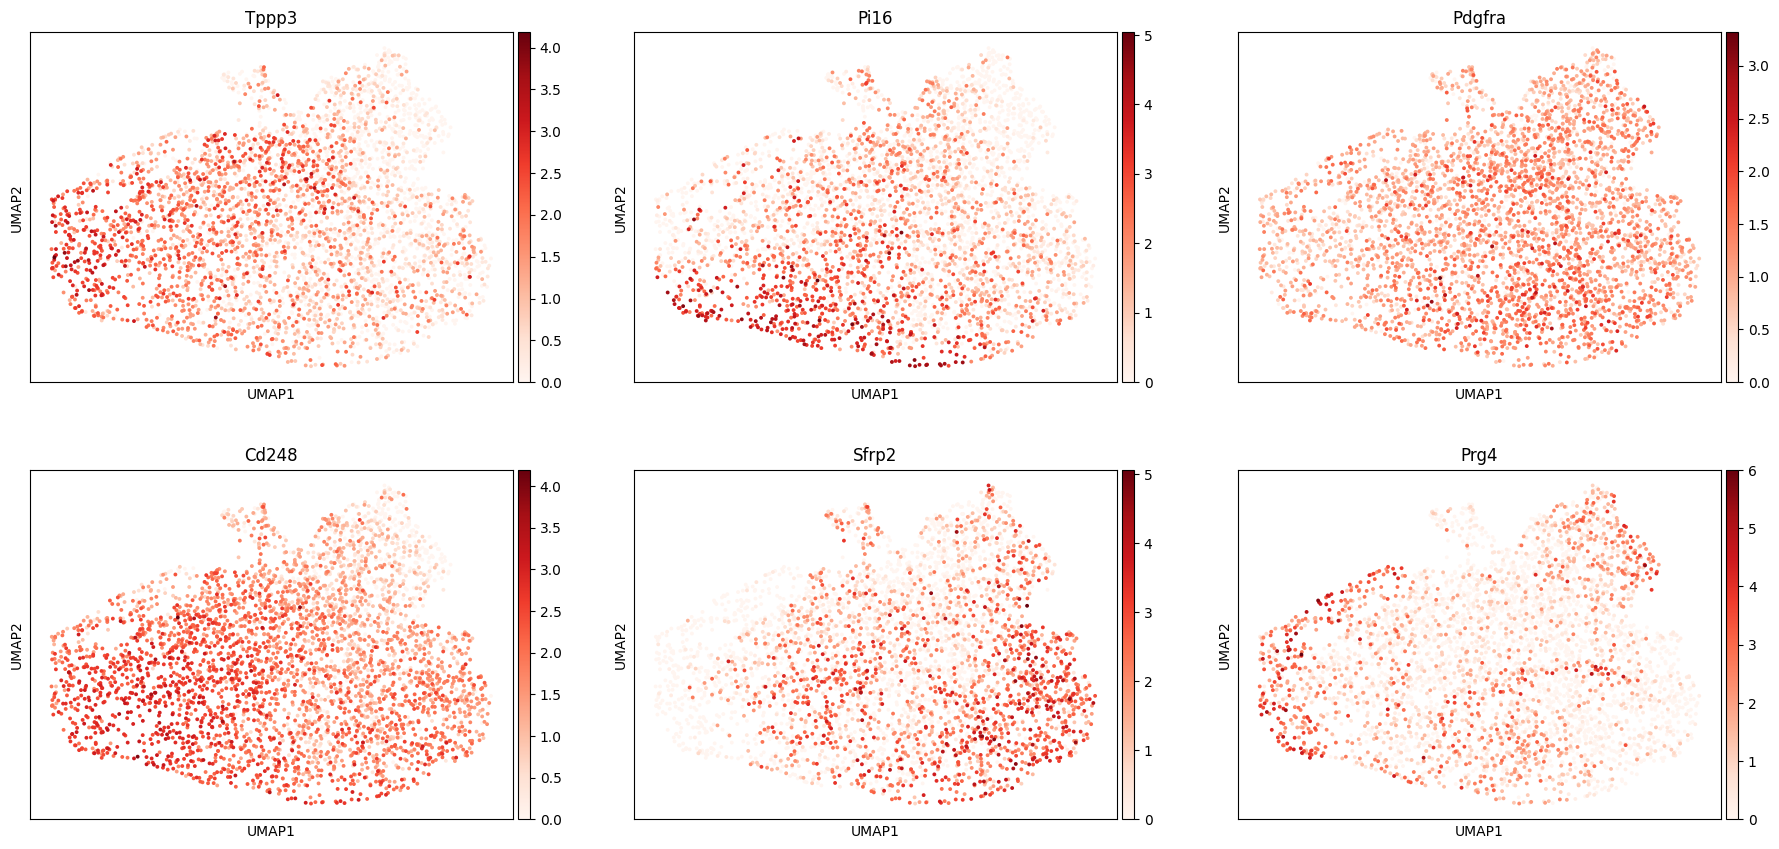

In [12]:
sc.pl.umap(
    sub,
    color=['Tppp3', 'Pi16', 'Pdgfra', 'Cd248', 'Sfrp2', 'Prg4'],
    ncols=3, cmap='Reds',
    save='_sub8_gene_overlays.png'
)

**Marker findings (from numerical table):**

*Note: "frac" is the fraction of cells with above-average scaled expression (> 0 in z-scored `.X`), not raw detection fraction. A mean near zero means expression sits at the dataset-wide average for that gene; negative means below average.*

| Sub-cluster | Tppp3 (mean / frac) | Pi16 (mean / frac) | Sfrp2 (mean / frac) | Pdgfra (mean / frac) | Identity |
|---|---|---|---|---|---|
| 0 | 0.586 / 0.619 | 0.718 / 0.579 | 0.862 / 0.571 | 1.045 / 0.865 | Stromal |
| 1 | 0.282 / 0.516 | **1.633 / 0.708** | **1.347 / 0.659** | **1.482 / 0.905** | T-FAP |
| 2 | -0.082 / 0.342 | 0.431 / 0.413 | 0.305 / 0.385 | 1.068 / 0.860 | Tenogenic progenitor |
| 3 | **1.755 / 0.945** | 1.235 / 0.588 | -0.005 / 0.235 | 0.781 / 0.792 | TSPC |

**Key discriminators:**
- **Tppp3** separates cluster 3 from all others (94.5% above-average, mean 1.755 — far above the rest)
- **Sfrp2** is the most informative T-FAP marker: cluster 1 highest (1.347), cluster 3 lowest (mean −0.005 — at the dataset average, indicating near-complete absence from TSPC relative to the full dataset)
- **Pi16** also highest in cluster 1 (1.633), confirming T-FAP identity. Note: Pi16 is also moderately elevated in TSPC (cluster 3, mean=1.235, 58.8%), so Pi16 alone is insufficient to distinguish T-FAP from TSPC — Sfrp2 provides the cleaner separation
- **Pdgfra** highest in cluster 1 (1.482) and lowest in cluster 3 (0.781). All cells are PDGFRα+ (this is cluster 8), but T-FAPs express it at higher relative levels

**Harvey 2019 markers that do not transfer to this dataset:**
- **Dpp4:** highest in TSPC (cluster 3, mean=1.425, 48.8%) rather than T-FAP (cluster 1, 0.708 / 24.1%). Not a T-FAP discriminator in the Achilles injury context.
- **Ly6a (Sca-1):** highest in TSPC (cluster 3, mean=1.785, 99.3%) and nearly universal across all sub-clusters (88–99% above-average), giving it no discriminating power. **Sfrp2 is the definitive T-FAP marker in this dataset.**

**Cluster 2 (Tenogenic progenitor):** Tppp3-negative (mean −0.082), low Pi16 and Sfrp2. Unbiased DEGs (§6) show this cluster is defined by tendon ECM genes — Thbs4, Kera, Col11a1 — indicating active commitment toward a tenogenic fate rather than quiescence. Condition enrichment is assessed in §7.

## 6. Differential expression between sub-clusters

Rank genes that best distinguish each sub-cluster. The top DEGs per cluster will seed the pySCENIC TF inference and the feature selection step in the classifier.

ranking genes
    finished (0:00:04)
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden_sub']`


c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (
c:\Users\fangy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (
C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\2153526534.py:6: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.rank_gen

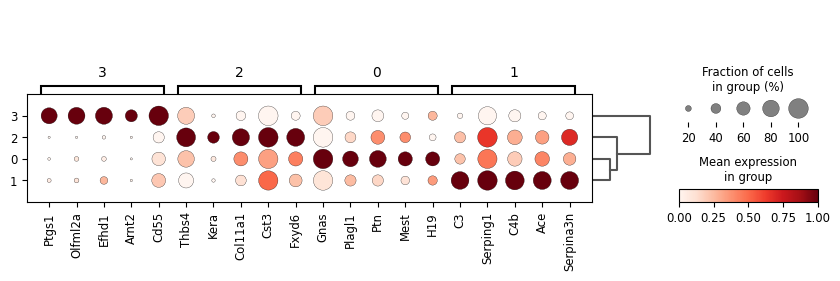

In [13]:
sc.tl.rank_genes_groups(
    sub, groupby='leiden_sub',
    method='wilcoxon', tie_correct=True
)

sc.pl.rank_genes_groups_dotplot(
    sub, n_genes=5,
    standard_scale='var',
    save='_sub8_top_degs.png'
)

In [14]:
deg_table = sc.get.rank_genes_groups_df(sub, group=None)
deg_table.to_csv('../../data/Cherief_scRNA-seq/cluster8_sub_DEGs.csv', index=False)
print('Top 5 genes per sub-cluster:')
print(deg_table.groupby('group').head(5)[['group', 'names', 'scores', 'pvals_adj']])

Top 5 genes per sub-cluster:
      group      names     scores      pvals_adj
0         0       Gnas  23.336954  2.034457e-116
1         0     Plagl1  21.945890  6.876015e-103
2         0        Ptn  21.346283   1.837597e-97
3         0       Mest  20.437046   2.841273e-89
4         0        H19  20.236290   1.276233e-87
21761     1         C3  35.867290  2.151838e-277
21762     1   Serping1  34.800243  2.624131e-261
21763     1        C4b  33.697453  4.569429e-245
21764     1        Ace  28.892094  8.164645e-180
21765     1  Serpina3n  27.172651  5.951417e-159
43522     2      Thbs4  26.600195  1.469499e-151
43523     2       Kera  25.465721  5.144413e-139
43524     2    Col11a1  25.030890  1.533808e-134
43525     2       Cst3  24.666965  1.053374e-130
43526     2      Fxyd6  24.559948  1.228155e-129
65283     3      Ptgs1  38.254807   0.000000e+00
65284     3    Olfml2a  35.695042  5.134719e-275
65285     3      Efhd1  30.456465  7.134730e-200
65286     3      Arnt2  30.306559  5.111

C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\4178897628.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(deg_table.groupby('group').head(5)[['group', 'names', 'scores', 'pvals_adj']])


**DEG interpretation — top 5 unbiased markers per sub-cluster:**

These genes are selected purely by statistical discrimination (Wilcoxon), independent of the candidate markers used in §5.

| Sub-cluster | Top DEGs | Biological interpretation |
|---|---|---|
| 3 (TSPC) | Ptgs1, Olfml2a, Efhd1, Arnt2, Cd55 | Cd55 (DAF) is a complement regulator expressed on progenitor cell surfaces; Ptgs1 (COX-1) drives prostaglandin-mediated tissue repair signaling |
| 2 (Tenogenic prog.) | Thbs4, Kera, Col11a1, Cst3, Fxyd6 | Thbs4 (Thrombospondin-4), Kera (Keratocan), and Col11a1 are tendon-specific ECM genes — this population is already expressing the tendon matrix program, supporting a tenogenic rather than quiescent identity |
| 0 (Stromal) | Gnas, Plagl1, Ptn, Mest, H19 | Plagl1, Mest, and H19 are all imprinted genes — an unusual epigenetic signature suggesting this stromal state has a developmentally distinct origin or regulatory program |
| 1 (T-FAP) | C3, Serping1, C4b, Ace, Serpina3n | **C3, C4b, and Serping1 are complement cascade genes** — T-FAPs are the major complement-producing cell type in this injured tendon. Complement activation drives local inflammation and is mechanistically linked to fibrosis in multiple tissues. This may explain how T-FAP activation leads to scarring rather than regeneration. |

**Key finding:** The T-FAP complement signature (C3/C4b/Serping1) is a novel observation not reported in Harvey 2019. It reframes T-FAPs not just as fibrogenic progenitors but as active drivers of complement-mediated inflammation in the injury environment. This is a candidate mechanism worth investigating in downstream analyses (e.g., LIANA can detect complement ligand-receptor interactions between T-FAPs and immune cells).

## 7. Condition split across sub-clusters

Denervation (TrkAF592A) is expected to deplete TSPCs and shift progenitors toward a fibrotic state. The proportional shift between conditions across sub-clusters quantifies this effect within cluster 8.

C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\3472489349.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(sub, color='condition', save='_sub8_condition.png')


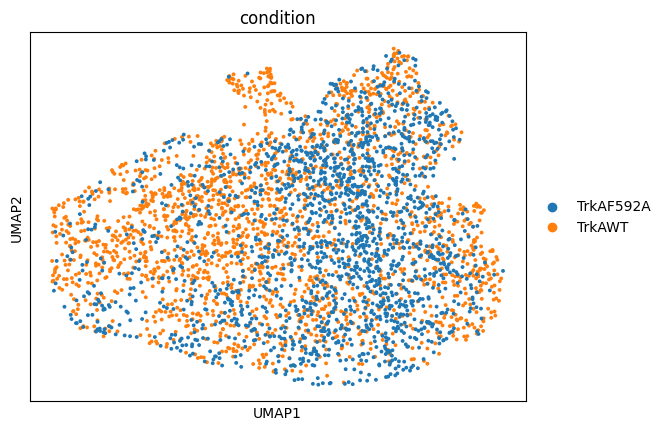

In [15]:
sc.pl.umap(sub, color='condition', save='_sub8_condition.png')

C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\1296716605.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['condition', 'leiden_sub'])


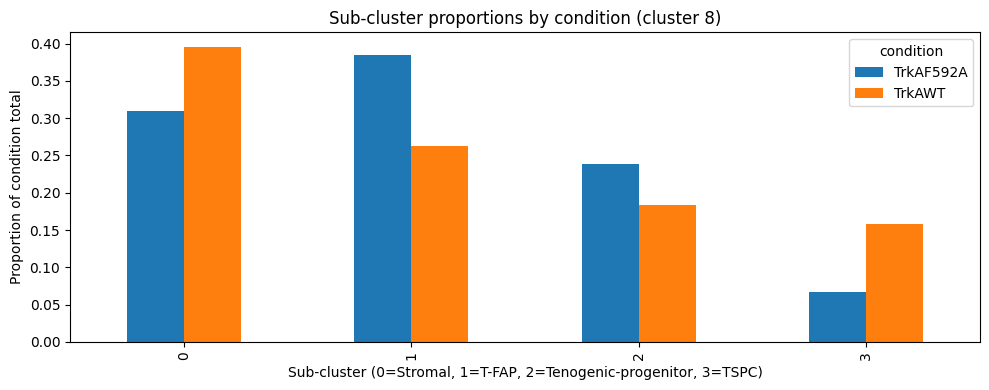


Proportions within each condition (rows sum to 1):
leiden_sub      0      1      2      3
condition                             
TrkAF592A   0.310  0.384  0.239  0.067
TrkAWT      0.395  0.263  0.184  0.158

Absolute counts:
leiden_sub    0    1    2    3
condition                     
TrkAF592A   560  694  431  121
TrkAWT      828  551  385  330


C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\1296716605.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub.obs.groupby(['condition', 'leiden_sub']).size().unstack(fill_value=0))


In [16]:
props = (
    sub.obs
    .groupby(['condition', 'leiden_sub'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum(), axis=1)
)

ax = props.T.plot(
    kind='bar', figsize=(10, 4),
    title='Sub-cluster proportions by condition (cluster 8)'
)
ax.set_xlabel('Sub-cluster (0=Stromal, 1=T-FAP, 2=Tenogenic-progenitor, 3=TSPC)')
ax.set_ylabel('Proportion of condition total')
plt.tight_layout()
plt.savefig('../../figures/Cherief_scRNA-seq/sub8_condition_proportions.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nProportions within each condition (rows sum to 1):')
print(props.round(3))

print('\nAbsolute counts:')
print(sub.obs.groupby(['condition', 'leiden_sub']).size().unstack(fill_value=0))

**What to look for:** Cluster 3 (TSPC) should be proportionally higher in TrkAWT — this is the Tppp3-high population that co-localises with the TrkAWT-enriched UMAP protrusion in the sanity check. Cluster 1 (T-FAP) should be relatively more represented in TrkAF592A. The condition directions for cluster 0 (Stromal) and cluster 2 (Tenogenic-progenitor) are not strongly predicted a priori. Interpretation of the printed proportions is in §8.

## 8. Annotate sub-clusters

Annotations are based on two independent lines of evidence:
1. **Candidate marker table (§5):** Tppp3 and Sfrp2 are the primary discriminators. Dpp4 and Ly6a (Harvey 2019 T-FAP markers) were found unreliable in this dataset — both are highest in the TSPC cluster.
2. **Unbiased DEGs (§6):** Top Wilcoxon genes per cluster confirm identities and reveal novel biology (complement signature in T-FAP; tendon ECM signature in cluster 2).

**Stromal (cluster 0) annotation note:** Cluster 0 shows intermediate Sfrp2 (0.862) and Pi16 (0.718) — elevated enough to appear T-FAP-like on the marker table alone. The definitive evidence for a distinct identity is the unbiased DEG profile: top genes are imprinted loci (Plagl1, Mest, H19), which are epigenetically distinct from the complement-driven T-FAP signature (C3, C4b, Serping1). These represent mutually exclusive regulatory programs, supporting a separate cell state. The marker table supports distinction from TSPC, but the DEGs are the primary evidence separating Stromal from T-FAP.

Note: cluster 2 is labeled **Tenogenic progenitor** (not quiescent) based on its top DEGs (Thbs4, Kera, Col11a1) — it is actively expressing tendon matrix genes, not in a dormant state.

C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\173618819.py:25: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


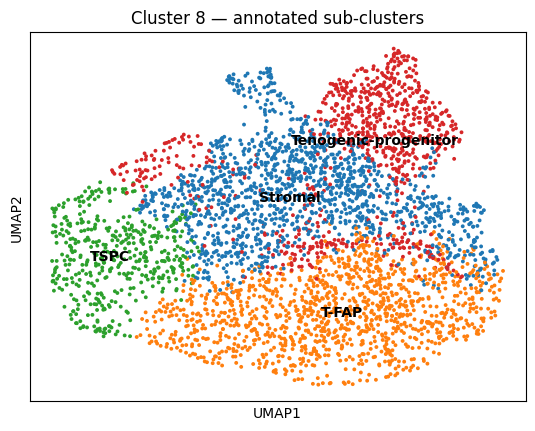

In [17]:
# Evidence for each label:
#   '0' Stromal:               Tppp3=0.586, Pi16=0.718, Sfrp2=0.862 — intermediate markers;
#                              identity established by DEGs: imprinted genes (Plagl1, Mest, H19)
#   '1' T-FAP:                 Tppp3=0.282 (lowest), Pi16=1.633, Sfrp2=1.347, Pdgfra=1.482 (all highest);
#                              complement DEGs (C3, C4b, Serping1); TrkAF592A-enriched (38.4% vs 26.3%)
#   '2' Tenogenic-progenitor:  Tppp3=-0.082 (below avg), Pi16/Sfrp2 low; tendon ECM DEGs (Thbs4, Kera, Col11a1);
#                              mildly TrkAF592A-enriched (23.9% vs 18.4%)
#   '3' TSPC:                  Tppp3=1.755 / 94.5% (highest by large margin), Sfrp2=-0.005 (near-absent);
#                              Cd55/Ptgs1 DEGs; strongly TrkAWT-enriched (15.8% vs 6.7%)

cluster_names = {
    '0': 'Stromal',
    '1': 'T-FAP',
    '2': 'Tenogenic-progenitor',
    '3': 'TSPC',
}

sub.obs['cell_type'] = (
    sub.obs['leiden_sub']
    .astype(str)          # cast Categorical → plain string to allow new category values
    .map(cluster_names)
    .fillna('Unknown')
)

sc.pl.umap(
    sub, color='cell_type',
    legend_loc='on data',
    title='Cluster 8 — annotated sub-clusters',
    save='_sub8_annotated.png'
)

In [18]:
print('Cells per annotation:')
print(sub.obs['cell_type'].value_counts())
print('\nCells per annotation per condition:')
print(sub.obs.groupby(['condition', 'cell_type']).size().unstack(fill_value=0))

Cells per annotation:
cell_type
Stromal                 1388
T-FAP                   1245
Tenogenic-progenitor     816
TSPC                     451
Name: count, dtype: int64

Cells per annotation per condition:
cell_type  Stromal  T-FAP  TSPC  Tenogenic-progenitor
condition                                            
TrkAF592A      560    694   121                   431
TrkAWT         828    551   330                   385


C:\Users\fangy\AppData\Local\Temp\ipykernel_14172\1762059758.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub.obs.groupby(['condition', 'cell_type']).size().unstack(fill_value=0))


**Condition split interpretation** (proportions normalised to condition totals: TrkAWT=2,094, TrkAF592A=1,806):

| Sub-cluster | TrkAWT | TrkAF592A | Direction |
|---|---|---|---|
| 0 (Stromal) | 39.5% (828/2094) | 31.0% (560/1806) | TrkAWT-enriched |
| 1 (T-FAP) | 26.3% (551/2094) | 38.4% (694/1806) | TrkAF592A-enriched |
| 2 (Tenogenic-progenitor) | 18.4% (385/2094) | 23.9% (431/1806) | TrkAF592A-enriched |
| 3 (TSPC) | 15.8% (330/2094) | 6.7% (121/1806) | TrkAWT-enriched (2.4×) |

**Key findings:**
- **TSPC (cluster 3):** Strongly TrkAWT-enriched (2.4-fold). This directly reproduces Cherief et al.'s core result: innervation maintains the Tppp3+ TSPC compartment.
- **T-FAP (cluster 1):** TrkAF592A-enriched (38.4% vs 26.3%). Denervation expands the complement-producing fibrogenic progenitor pool, consistent with the scarring phenotype.
- **Tenogenic-progenitor (cluster 2):** Mildly TrkAF592A-enriched (23.9% vs 18.4%). One interpretation: denervation may accelerate commitment from a stem-like TSPC state toward a tenogenic ECM-secreting fate — cells depleted from the TSPC compartment may transit through this state rather than returning to quiescence.
- **Stromal (cluster 0):** Mildly TrkAWT-enriched (39.5% vs 31.0%), suggesting innervation also supports the broader stromal compartment, though the effect is less pronounced than for TSPC.

## 9. Save

Save the sub-clustered object and propagate the `cell_type` annotation back onto the full object for use in downstream notebooks (pySCENIC, CellRank, LIANA).

In [19]:
sub.write('../../data/Cherief_scRNA-seq/GSE244921_cluster8_sub.h5ad')
print('Saved cluster 8 sub-object.')

# Propagate annotations back to the full object
full.obs['leiden_sub'] = full.obs['leiden'].astype(str)
full.obs.loc[sub.obs_names, 'leiden_sub'] = sub.obs['leiden_sub'].values
full.obs['cell_type'] = 'Other'
full.obs.loc[sub.obs_names, 'cell_type'] = sub.obs['cell_type'].values

full.write('../../data/Cherief_scRNA-seq/GSE244921_processed_subclustered.h5ad')
print('Updated full object saved.')
print('\nFinal cell_type distribution in full object:')
print(full.obs['cell_type'].value_counts())

Saved cluster 8 sub-object.
Updated full object saved.

Final cell_type distribution in full object:
cell_type
Other                   18715
Stromal                  1388
T-FAP                    1245
Tenogenic-progenitor      816
TSPC                      451
Name: count, dtype: int64
